# Global 모델링 Stage 3 — 사람이 선택한 25개 Feature의 2차 모델 비교

이 Notebook은 사람이 확정한 `global_stage2_selected_25` Feature set만 사용해 Logistic Regression과 XGBoost를 새로 튜닝한다. 1차 `best_params`는 재사용하지 않는다.

- 모델 개발: 고정 Global Train만 사용
- CV: `StratifiedGroupKFold`, 5-fold, group=`SAMPID`, random_state=42
- scoring / threshold: F1 / 0.5
- 전처리: 각 CV Train fold에서만 fit
- Test Dataset, `n_prior_periods`, `sample_weight`: 사용하지 않음

수치와 시각화만 제공한다. Feature set의 적절성이나 최종 모델은 선택하지 않는다.

In [1]:
import importlib
import json
import os
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

ROOT = Path(os.environ.get('KHUDA_PROJECT_ROOT', Path.cwd())).resolve()
while not (ROOT / 'code').is_dir():
    if ROOT.parent == ROOT:
        raise RuntimeError('KHUDA_PROJECT_ROOT에 저장소 루트를 지정하거나 저장소 안에서 Notebook을 실행하세요.')
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if 'code' in sys.modules and not hasattr(sys.modules['code'], '__path__'):
    del sys.modules['code']
for module_name in ('code.model.first_stage', 'code.pipeline.saved_results', 'code.preprocess.build_features'):
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

from code.model.first_stage import (
    first_stage_summary,
    load_stage_fold_f1,
    run_global_cv_modeling,
    save_modeling_artifacts,
)
from code.model.train import load_model_config
from code.pipeline.saved_results import load_saved_global_train, select_bundle_features
from code.preprocess.build_features import named_feature_set

EXPERIMENT = 'baseline_42features'
FEATURE_SET_NAME = 'global_stage2_selected_25'
RESULT_ROOT = ROOT / 'data' / 'result' / EXPERIMENT
DATASET_PATH = RESULT_ROOT / 'datasets' / 'global_dataset.parquet'
SPLIT_PATH = RESULT_ROOT / 'splits' / 'split_ids.csv'
FEATURE_CONFIG = ROOT / 'code' / 'config' / 'features.yaml'
MODEL_CONFIG = ROOT / 'code' / 'config' / 'model_config.yaml'
STAGE_1_OUTPUT_DIR = RESULT_ROOT / 'modeling' / 'stage_1'
STAGE_3_OUTPUT_DIR = RESULT_ROOT / 'modeling' / 'stage_3'

for path in (DATASET_PATH, SPLIT_PATH, FEATURE_CONFIG, MODEL_CONFIG):
    if not path.exists():
        raise FileNotFoundError(f'필요한 Stage 3 입력 파일이 없습니다: {path}')

COLORS = {'stage_1': '#7a7a7a', 'stage_2': '#0066cc'}
LABELS = {'logistic_regression': 'Logistic Regression', 'xgboost': 'XGBoost'}
plt.rcParams.update({
    'figure.facecolor': '#f5f5f7', 'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#e0e0e0', 'text.color': '#1d1d1f',
    'axes.labelcolor': '#1d1d1f', 'xtick.color': '#1d1d1f', 'ytick.color': '#1d1d1f',
})

In [2]:
# Test Dataset은 만들지 않는다. 42개 Global Train에서 사람이 확정한 Feature 열만 선택한다.
full_train_bundle = load_saved_global_train(DATASET_PATH, SPLIT_PATH, FEATURE_CONFIG)
selected_features = named_feature_set(FEATURE_CONFIG, FEATURE_SET_NAME)
train_bundle = select_bundle_features(
    full_train_bundle, selected_features, name='global_stage2_selected_25'
)
model_config = load_model_config(MODEL_CONFIG)
official_models = model_config['official_comparison_models']

stage_1_summary_path = STAGE_1_OUTPUT_DIR / 'first_stage_summary.csv'
if not stage_1_summary_path.exists():
    raise FileNotFoundError('Stage 1 summary가 없습니다. 01_first_model.ipynb의 결과 저장 셀을 먼저 실행하세요.')
stage_1_summary = pd.read_csv(stage_1_summary_path)
stage_1_fold_f1 = load_stage_fold_f1(STAGE_1_OUTPUT_DIR)
stage_1_oof = {
    model_name: pd.read_parquet(STAGE_1_OUTPUT_DIR / f'{model_name}_oof_predictions.parquet')
    for model_name in official_models
}

assert official_models == ['logistic_regression', 'xgboost']
assert full_train_bundle.X.shape[1] == 42
assert len(selected_features) == 25
assert list(train_bundle.X.columns) == selected_features
assert set(official_models).issubset(stage_1_fold_f1)
display(pd.DataFrame({'selected_feature_order': range(1, len(selected_features) + 1), 'feature': selected_features}))
display(pd.DataFrame({
    'item': ['Train Person-Periods', 'Train unique SAMPID', 'Stage 1 features', 'Stage 2 features', 'CV', 'scoring', 'threshold'],
    'value': [
        len(train_bundle.y), train_bundle.groups.nunique(), full_train_bundle.X.shape[1], train_bundle.X.shape[1],
        f"StratifiedGroupKFold({model_config['split']['cv_n_splits']}) / SAMPID",
        model_config['tuning']['scoring'], model_config['tuning']['threshold'],
    ],
}))

,selected_feature_order,feature
0,1,gender
1,2,age
2,3,region_5
3,4,baseline_year
4,5,education_level
5,6,student_status
6,7,student_type
7,8,university_type
8,9,major_group
9,10,months_since_graduation


,item,value
0,Train Person-Periods,11925
1,Train unique SAMPID,5737
2,Stage 1 features,42
3,Stage 2 features,25
4,CV,StratifiedGroupKFold(5) / SAMPID
5,scoring,f1
6,threshold,0.5


## 선택 Feature 기준 재튜닝

아래 셀은 25개 선택 Feature로 LR/XGBoost의 GridSearchCV를 처음부터 실행한다. Stage 1의 `best_params`는 이 단계의 학습 입력으로 사용하지 않는다.

In [3]:
stage_2_results = {}
for model_name in official_models:
    print(f"Running Stage 2 {LABELS[model_name]} ...")
    stage_2_results[model_name] = run_global_cv_modeling(
        train_bundle,
        model_name=model_name,
        feature_config=FEATURE_CONFIG,
        model_config=MODEL_CONFIG,
        # Jupyter의 code 패키지와 process worker 충돌을 피하기 위해 현재 kernel에서 순차 실행한다.
        n_jobs=1,
    )

stage_2_summary = first_stage_summary([stage_2_results[name] for name in official_models])
display(stage_2_summary)
display(pd.DataFrame([
    {
        'model': LABELS[name],
        'best_params': stage_2_results[name].best_params,
        'fold_f1': stage_2_results[name].fold_f1,
    }
    for name in official_models
]))

Running Stage 2 Logistic Regression ...


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ra

Running Stage 2 XGBoost ...


,model,n_features,best_cv_f1,cv_f1_mean,cv_f1_std,oof_precision,oof_recall,oof_f1,oof_roc_auc,best_params
0,logistic_regression,25,0.492616,0.492616,0.022458,0.421209,0.592747,0.492468,0.701449,"{'C': 0.1, 'class_weight': 'balanced', 'penalt..."
1,xgboost,25,0.507894,0.507894,0.016047,0.413689,0.657574,0.507870,0.710534,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."


,model,best_params,fold_f1
0,Logistic Regression,"{'C': 0.1, 'class_weight': 'balanced', 'penalt...","(0.4847682119205298, 0.5110073382254836, 0.458..."
1,XGBoost,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...","(0.4940883634100809, 0.5274861025324274, 0.489..."


In [4]:
# Stage 4 후보 비교에 재사용할 수 있도록 Stage 2 OOF·요약·파라미터·fold F1을 저장한다.
stage_2_paths = save_modeling_artifacts(
    [stage_2_results[name] for name in official_models],
    STAGE_3_OUTPUT_DIR,
    summary_filename='second_stage_summary.csv',
)
selected_feature_path = STAGE_3_OUTPUT_DIR / 'selected_features.csv'
pd.DataFrame({'feature_order': range(1, len(selected_features) + 1), 'feature': selected_features}).to_csv(
    selected_feature_path, index=False
)
stage_2_paths['selected_features'] = selected_feature_path
display(pd.DataFrame({'artifact': list(stage_2_paths), 'path': [str(path) for path in stage_2_paths.values()]}))

,artifact,path
0,logistic_regression_oof,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
1,xgboost_oof,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
2,summary,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
3,best_params,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
4,fold_f1,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
5,selected_features,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...


In [5]:
comparison_columns = [
    'model', 'stage', 'n_features', 'cv_f1_mean', 'cv_f1_std',
    'oof_precision', 'oof_recall', 'oof_f1', 'oof_roc_auc', 'best_params',
]
stage_1_comparison = stage_1_summary.copy()
stage_1_comparison['stage'] = 'Stage 1'
stage_2_comparison = stage_2_summary.copy()
stage_2_comparison['stage'] = 'Stage 2'
comparison = pd.concat([stage_1_comparison, stage_2_comparison], ignore_index=True)[comparison_columns]
comparison['model_label'] = comparison['model'].map(LABELS)
display(comparison[comparison_columns])

,model,stage,n_features,cv_f1_mean,cv_f1_std,oof_precision,oof_recall,oof_f1,oof_roc_auc,best_params
0,logistic_regression,Stage 1,42,0.491064,0.023322,0.420403,0.589859,0.490919,0.702318,"{'C': 1, 'class_weight': 'balanced', 'penalty'..."
1,xgboost,Stage 1,42,0.505448,0.015153,0.412277,0.653081,0.505464,0.710588,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
2,logistic_regression,Stage 2,25,0.492616,0.022458,0.421209,0.592747,0.492468,0.701449,"{'C': 0.1, 'class_weight': 'balanced', 'penalt..."
3,xgboost,Stage 2,25,0.507894,0.016047,0.413689,0.657574,0.507870,0.710534,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."


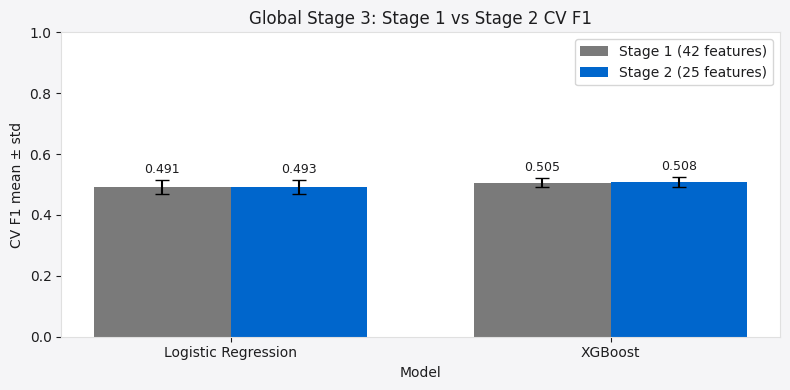

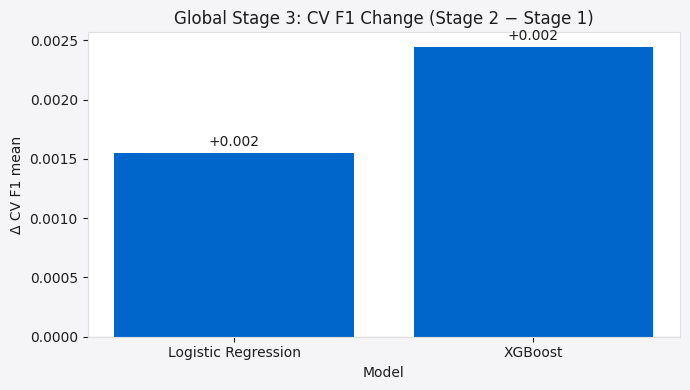

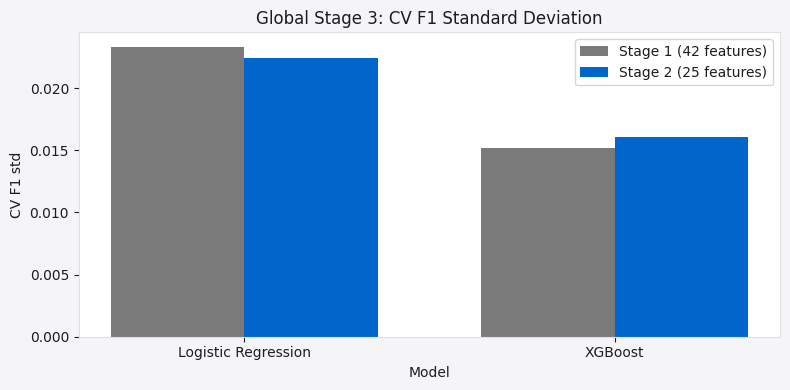

In [6]:
def stage_values(metric):
    first = comparison[comparison['stage'] == 'Stage 1'].set_index('model')[metric]
    second = comparison[comparison['stage'] == 'Stage 2'].set_index('model')[metric]
    return first.reindex(official_models), second.reindex(official_models)

x = np.arange(len(official_models))
width = 0.36

# 1. 1차 vs 2차 CV F1 비교
stage_1_f1, stage_2_f1 = stage_values('cv_f1_mean')
stage_1_std, stage_2_std = stage_values('cv_f1_std')
fig, ax = plt.subplots(figsize=(8, 4))
bars_1 = ax.bar(x - width / 2, stage_1_f1, width, yerr=stage_1_std, capsize=5, color=COLORS['stage_1'], label='Stage 1 (42 features)')
bars_2 = ax.bar(x + width / 2, stage_2_f1, width, yerr=stage_2_std, capsize=5, color=COLORS['stage_2'], label='Stage 2 (25 features)')
ax.bar_label(bars_1, labels=[f'{value:.3f}' for value in stage_1_f1], padding=3, fontsize=9)
ax.bar_label(bars_2, labels=[f'{value:.3f}' for value in stage_2_f1], padding=3, fontsize=9)
ax.set_title('Global Stage 3: Stage 1 vs Stage 2 CV F1')
ax.set_xlabel('Model')
ax.set_ylabel('CV F1 mean ± std')
ax.set_xticks(x, [LABELS[name] for name in official_models])
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

# 2. 모델별 CV F1 변화량
delta_f1 = stage_2_f1 - stage_1_f1
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([LABELS[name] for name in official_models], delta_f1, color='#0066cc')
ax.bar_label(bars, labels=[f'{value:+.3f}' for value in delta_f1], padding=3)
ax.axhline(0, color='#6e6e73', linewidth=0.8)
ax.set_title('Global Stage 3: CV F1 Change (Stage 2 − Stage 1)')
ax.set_xlabel('Model')
ax.set_ylabel('Δ CV F1 mean')
plt.tight_layout()
plt.show()

# 3. 1차 vs 2차 CV F1 std 비교
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width / 2, stage_1_std, width, color=COLORS['stage_1'], label='Stage 1 (42 features)')
ax.bar(x + width / 2, stage_2_std, width, color=COLORS['stage_2'], label='Stage 2 (25 features)')
ax.set_title('Global Stage 3: CV F1 Standard Deviation')
ax.set_xlabel('Model')
ax.set_ylabel('CV F1 std')
ax.set_xticks(x, [LABELS[name] for name in official_models])
ax.legend()
plt.tight_layout()
plt.show()

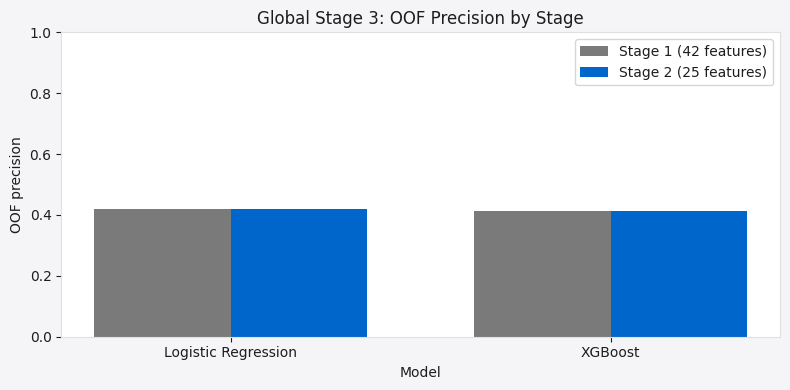

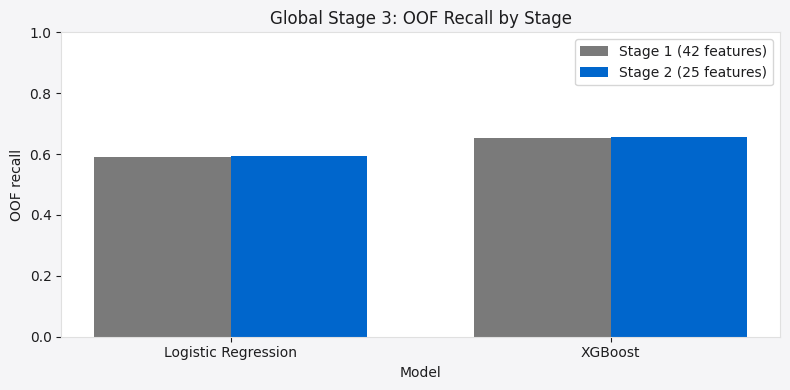

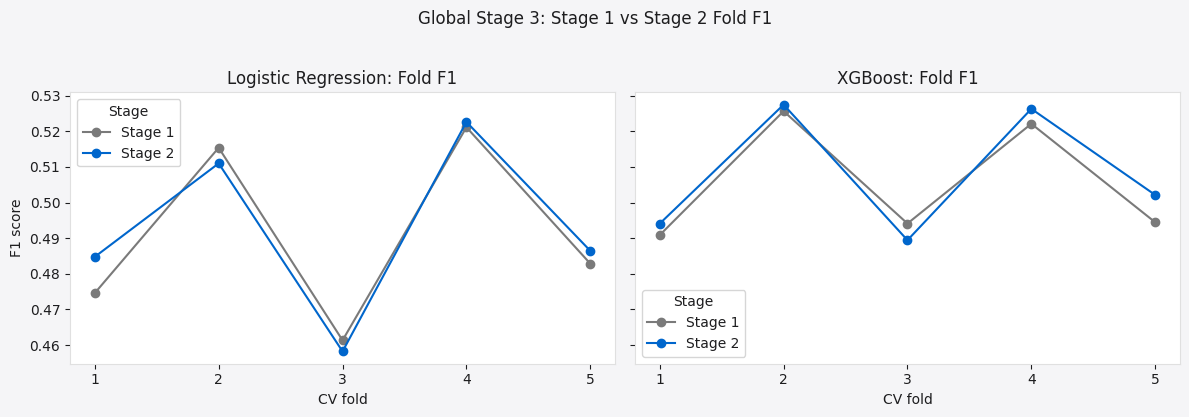

,model,stage,fold,f1
0,logistic_regression,Stage 1,1,0.474599
1,logistic_regression,Stage 1,2,0.515395
2,logistic_regression,Stage 1,3,0.461332
3,logistic_regression,Stage 1,4,0.521146
4,logistic_regression,Stage 1,5,0.482848
5,logistic_regression,Stage 2,1,0.484768
6,logistic_regression,Stage 2,2,0.511007
7,logistic_regression,Stage 2,3,0.458221
8,logistic_regression,Stage 2,4,0.522634
9,logistic_regression,Stage 2,5,0.486452


In [7]:
def plot_stage_metric(metric, title, y_label):
    first, second = stage_values(metric)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - width / 2, first, width, color=COLORS['stage_1'], label='Stage 1 (42 features)')
    ax.bar(x + width / 2, second, width, color=COLORS['stage_2'], label='Stage 2 (25 features)')
    ax.set_title(title)
    ax.set_xlabel('Model')
    ax.set_ylabel(y_label)
    ax.set_xticks(x, [LABELS[name] for name in official_models])
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    plt.show()

# 4-5. Precision / Recall 변화
plot_stage_metric('oof_precision', 'Global Stage 3: OOF Precision by Stage', 'OOF precision')
plot_stage_metric('oof_recall', 'Global Stage 3: OOF Recall by Stage', 'OOF recall')

# 6. Fold별 F1 비교
fold_rows = []
for model_name in official_models:
    for fold, score in enumerate(stage_1_fold_f1[model_name], start=1):
        fold_rows.append({'model': model_name, 'stage': 'Stage 1', 'fold': fold, 'f1': score})
    for fold, score in enumerate(stage_2_results[model_name].fold_f1, start=1):
        fold_rows.append({'model': model_name, 'stage': 'Stage 2', 'fold': fold, 'f1': score})
fold_comparison = pd.DataFrame(fold_rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, model_name in zip(axes, official_models):
    subset = fold_comparison[fold_comparison['model'] == model_name]
    for stage, color in [('Stage 1', COLORS['stage_1']), ('Stage 2', COLORS['stage_2'])]:
        values = subset[subset['stage'] == stage].sort_values('fold')
        ax.plot(values['fold'], values['f1'], marker='o', color=color, label=stage)
    ax.set_title(f"{LABELS[model_name]}: Fold F1")
    ax.set_xlabel('CV fold')
    ax.set_xticks(range(1, model_config['split']['cv_n_splits'] + 1))
    ax.legend(title='Stage')
axes[0].set_ylabel('F1 score')
fig.suptitle('Global Stage 3: Stage 1 vs Stage 2 Fold F1', y=1.03)
fig.tight_layout()
plt.show()
display(fold_comparison)

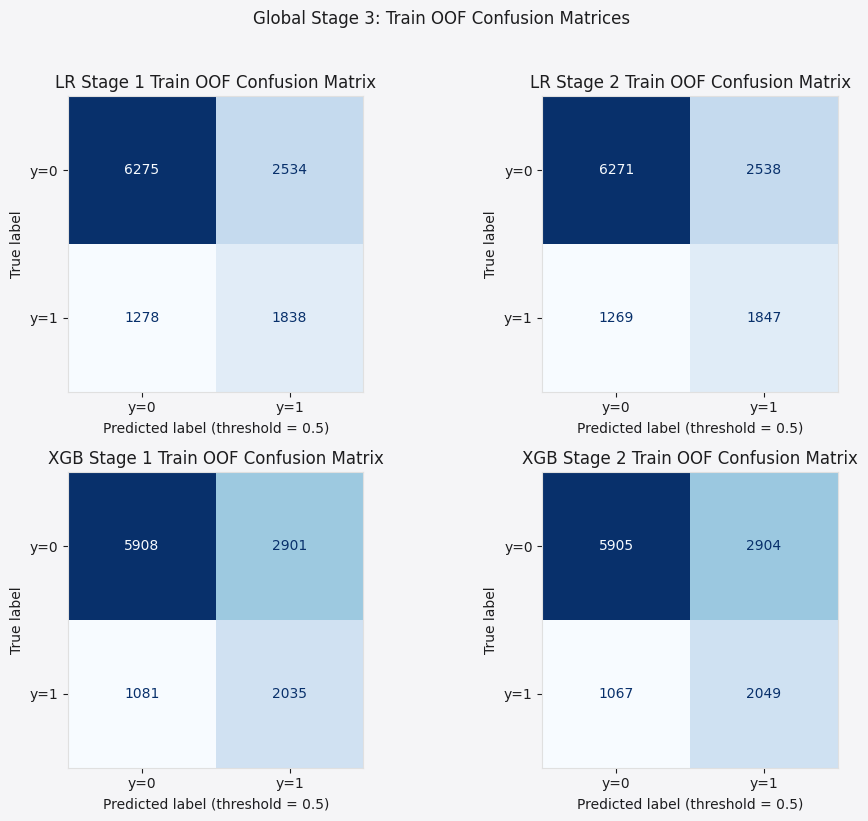

In [8]:
# 7. 네 후보의 Train OOF Confusion Matrix. Test Dataset은 사용하지 않는다.
candidate_oof = {
    'LR Stage 1': stage_1_oof['logistic_regression'],
    'LR Stage 2': stage_2_results['logistic_regression'].oof_predictions,
    'XGB Stage 1': stage_1_oof['xgboost'],
    'XGB Stage 2': stage_2_results['xgboost'].oof_predictions,
}
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (label, prediction) in zip(axes.ravel(), candidate_oof.items()):
    matrix = confusion_matrix(prediction['y_true'], prediction['y_predicted'], labels=[0, 1])
    ConfusionMatrixDisplay(matrix, display_labels=['y=0', 'y=1']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{label} Train OOF Confusion Matrix')
    ax.set_xlabel('Predicted label (threshold = 0.5)')
    ax.set_ylabel('True label')
fig.suptitle('Global Stage 3: Train OOF Confusion Matrices', y=1.02)
fig.tight_layout()
plt.show()

## 최종 비교표

이 Notebook은 1차/2차의 Train 내부 CV·OOF 수치와 시각화만 제공한다. 어느 모델을 Stage 4의 Test 평가 대상으로 올릴지는 사람이 직접 결정한다.

In [9]:
display(comparison[comparison_columns])

,model,stage,n_features,cv_f1_mean,cv_f1_std,oof_precision,oof_recall,oof_f1,oof_roc_auc,best_params
0,logistic_regression,Stage 1,42,0.491064,0.023322,0.420403,0.589859,0.490919,0.702318,"{'C': 1, 'class_weight': 'balanced', 'penalty'..."
1,xgboost,Stage 1,42,0.505448,0.015153,0.412277,0.653081,0.505464,0.710588,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
2,logistic_regression,Stage 2,25,0.492616,0.022458,0.421209,0.592747,0.492468,0.701449,"{'C': 0.1, 'class_weight': 'balanced', 'penalt..."
3,xgboost,Stage 2,25,0.507894,0.016047,0.413689,0.657574,0.507870,0.710534,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
